# TPC_RP Algorithm Implementation — CIFAR-10
## CW2: Machine Learning (5CCSAMLF)

This notebook implements the TPC_RP variant of the TypiClust algorithm from:

> Hacohen, G., Dekel, A., & Weinshall, D. (2022). *Active Learning on a Budget: Opposite Strategies Suit High and Low Budgets.* ICML 2022.

**TPC_RP** selects typical and diverse examples for labeling in the low-budget active learning regime, using:
1. SimCLR for self-supervised representation learning
2. K-Means for clustering (diversity)
3. Typicality-based selection (density)


---
## 1. Setup: Install Libraries & Imports

Install and import all necessary libraries. You will need:
- `torch`, `torchvision` — for neural networks and CIFAR-10
- `scikit-learn` — for K-Means clustering and nearest neighbours
- `numpy` — for numerical operations
- `matplotlib` — for plotting results

Also set up:
- Random seeds for reproducibility
- GPU device detection


In [ ]:
# Install packages and import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torchvision.models import resnet18

import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt
import random

#from google.colab import drive
#drive.mount('/content/drive')






In [ ]:
# Set seed for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


---
## 2. Load CIFAR-10 Dataset

CIFAR-10 contains 60,000 colour images (32×32 pixels) in 10 classes:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

- 50,000 training images
- 10,000 test images

Use `torchvision.datasets.CIFAR10` with `download=True`.

Define a basic transform with `ToTensor()` and normalization:
- Mean: (0.4914, 0.4822, 0.4465)
- Std: (0.2470, 0.2435, 0.2616)


In [ ]:
# Load CIFAR-10 training and test sets
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=basic_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=basic_transform)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

/home/sdm/.pyenv/versions/3.13.0/envs/fundus_lesion_seg/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training set size: 50000
Test set size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


---
## 3. Step 1 — SimCLR: Self-Supervised Representation Learning

SimCLR learns meaningful image representations **without labels** by:
1. Taking each image and creating two different augmented versions of it
2. Training the network to recognise that both versions came from the same image
3. The network learns general visual features in the process

**Paper settings (Appendix F.1):**
- Backbone: ResNet18
- Projection head: MLP projecting to 128 dimensions
- Epochs: 500 (can reduce to 100-200 for speed)
- Optimizer: SGD, momentum 0.9, learning rate 0.4, cosine scheduler
- Batch size: 512
- Weight decay: 0.0001
- Augmentations: random resized crops, horizontal flips, colour jitter, random grayscale
- Feature space: L2-normalized 512-dim penultimate layer


### 3.1 SimCLR Data Augmentations

Create a class that takes one image and returns **two** differently augmented versions.

Augmentations to apply:
- `RandomResizedCrop(32, scale=(0.2, 1.0))`
- `RandomHorizontalFlip()`
- `ColorJitter(0.4, 0.4, 0.4, 0.1)` applied with probability 0.8
- `RandomGrayscale(p=0.2)`
- `ToTensor()` and `Normalize()`


In [ ]:
# SimCLR augmentation class and DataLoader
class SimCLRAugmentation:
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(32, scale=(0.2, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([
                transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
            ], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
        ])

    def __call__(self, x):
        return self.transform(x), self.transform(x)

# Create dataset with SimCLR augmentations
simclr_train_dataset = datasets.CIFAR10(
    root='./data', train=True, download=False,
    transform=SimCLRAugmentation()
)

# Create DataLoader
simclr_loader = DataLoader(simclr_train_dataset, batch_size=512, shuffle=True,
                           num_workers=4, pin_memory=True, drop_last=True)

print(f"SimCLR dataloader ready: {len(simclr_loader)} batches of size 512")

SimCLR dataloader ready: 97 batches of size 512


### 3.2 SimCLR Model (ResNet18 + Projection Head)

Build a model with two parts:
- **Encoder**: ResNet18 with the final fully-connected layer removed → outputs 512-dim features
- **Projection head**: MLP (512 → 512 → 128) used only during SimCLR training

Hint: Use `torchvision.models.resnet18()` and remove the last layer using `nn.Sequential(*list(resnet.children())[:-1])`


In [ ]:
#Define SimCLR model class

class SimCLRModel(nn.Module):
    def __init__(self, feature_dim=128):
        super(SimCLRModel, self).__init__()

        #ResNet18 encoder
        backbone = resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])

        #Projection head
        self.projection_head = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, feature_dim)
        )

    def forward(self, x):
        # Get 512-dim features from encoder
        features = self.encoder(x)
        features = features.squeeze()

        # Get 128-dim projections for contrastive learning
        projections = self.projection_head(features)

        return features, projections

model_simclr = SimCLRModel(feature_dim=128).to(device)
print(f"SimCLR model created. Parameters: {sum(p.numel() for p in model_simclr.parameters()):,}")

SimCLR model created. Parameters: 11,504,832


### 3.3 NT-Xent Loss (SimCLR Contrastive Loss)

The contrastive loss that makes SimCLR work:
- For each image, its two augmented views are a **positive pair** (should be similar)
- All other images' views are **negative pairs** (should be different)
- Uses temperature scaling (temperature = 0.5)

Steps:
1. L2 normalize the projection vectors
2. Compute cosine similarity matrix between all pairs
3. Divide by temperature
4. Use cross-entropy loss where the correct "class" is the positive pair


In [ ]:
# YOUR CODE HERE: Define NT-Xent contrastive loss
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]

        z_i = F.normalize(z_i, dim=1)
        z_j = F.normalize(z_j, dim=1)

        z = torch.cat([z_i, z_j], dim=0)

        sim_matrix = torch.mm(z, z.t()) / self.temperature

        mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
        sim_matrix = sim_matrix.masked_fill(mask, -9e15)

        labels_ij = torch.arange(batch_size, 2 * batch_size, device=z.device)
        labels_ji = torch.arange(0, batch_size, device=z.device)
        labels = torch.cat([labels_ij, labels_ji], dim=0)

        loss = self.criterion(sim_matrix, labels)
        return loss

criterion_simclr = NTXentLoss(temperature=0.5)
print("NT-Xent loss function ready")

NT-Xent loss function ready


### 3.4 Train SimCLR

Training loop:
- For each epoch, iterate through batches
- Each batch gives you two views (x_i, x_j) of the same images
- Pass both through the model to get projections z_i, z_j
- Compute NT-Xent loss on z_i, z_j
- Backpropagate and update weights
- Step the cosine learning rate scheduler after each epoch

**Note:** This is the most time-consuming step. 200 epochs on Colab GPU takes a few hours.


In [ ]:
NUM_EPOCHS_SIMCLR = 500
LEARNING_RATE_SIMCLR = 0.4
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0001

optimizer_simclr = optim.SGD(
    model_simclr.parameters(),
    lr=LEARNING_RATE_SIMCLR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

scheduler_simclr = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_simclr, T_max=NUM_EPOCHS_SIMCLR
)

print(f"Starting SimCLR training for {NUM_EPOCHS_SIMCLR} epochs...")
losses = []

for epoch in range(NUM_EPOCHS_SIMCLR):
    model_simclr.train()
    epoch_loss = 0.0
    num_batches = 0

    for (x_i, x_j), _ in simclr_loader:
        x_i, x_j = x_i.to(device), x_j.to(device)

        _, z_i = model_simclr(x_i)
        _, z_j = model_simclr(x_j)

        loss = criterion_simclr(z_i, z_j)

        optimizer_simclr.zero_grad()
        loss.backward()
        optimizer_simclr.step()

        epoch_loss += loss.item()
        num_batches += 1

    scheduler_simclr.step()
    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS_SIMCLR}] - Loss: {avg_loss:.4f}")

print("SimCLR training complete!")

Starting SimCLR training for 500 epochs...
Epoch [10/500] - Loss: 5.6771
Epoch [20/500] - Loss: 5.5747
Epoch [30/500] - Loss: 5.5264
Epoch [40/500] - Loss: 5.4922
Epoch [50/500] - Loss: 5.4773
Epoch [60/500] - Loss: 5.4608
Epoch [70/500] - Loss: 5.4551
Epoch [80/500] - Loss: 5.4451
Epoch [90/500] - Loss: 5.4375
Epoch [100/500] - Loss: 5.4274
Epoch [110/500] - Loss: 5.4268
Epoch [120/500] - Loss: 5.4193
Epoch [130/500] - Loss: 5.4164
Epoch [140/500] - Loss: 5.4142
Epoch [150/500] - Loss: 5.4126
Epoch [160/500] - Loss: 5.4090
Epoch [170/500] - Loss: 5.3998
Epoch [180/500] - Loss: 5.3990
Epoch [190/500] - Loss: 5.3937
Epoch [200/500] - Loss: 5.3911
Epoch [210/500] - Loss: 5.3914
Epoch [220/500] - Loss: 5.3836
Epoch [230/500] - Loss: 5.3805
Epoch [240/500] - Loss: 5.3757
Epoch [250/500] - Loss: 5.3749
Epoch [260/500] - Loss: 5.3709
Epoch [270/500] - Loss: 5.3624
Epoch [280/500] - Loss: 5.3630
Epoch [290/500] - Loss: 5.3526
Epoch [300/500] - Loss: 5.3506
Epoch [310/500] - Loss: 5.3471
Epoch

In [ ]:
torch.save(model_simclr.state_dict(), 'simclr_model_500epochs.pth')
print("Model saved")

Model saved


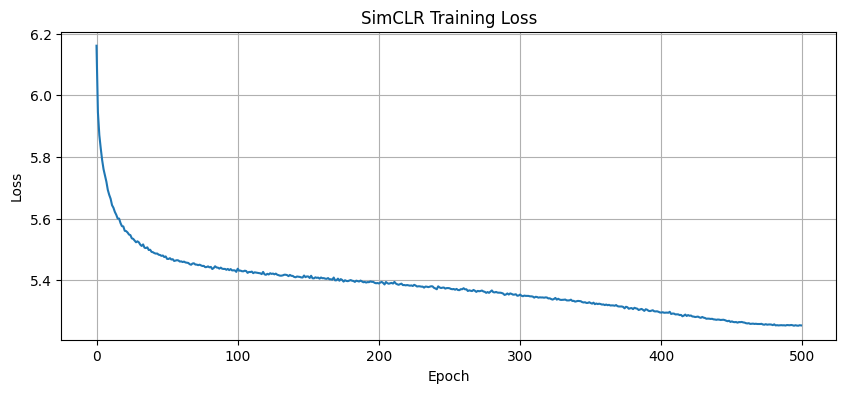

In [ ]:
#  Plot the SimCLR training loss curve
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SimCLR Training Loss')
plt.grid(True)
plt.savefig('simclr_training_loss.png', dpi=150)
plt.show()


---
## 4. Extract Features from Trained SimCLR

After training SimCLR, extract features for all 50,000 training images:
1. Use the **basic transform** (no SimCLR augmentations)
2. Pass each image through the SimCLR encoder (not the projection head)
3. Get the 512-dimensional feature vector
4. **L2 normalize** each feature vector (as stated in Appendix F.1)

Use `torch.no_grad()` since we're not training here.

Expected output shape: (50000, 512)


In [ ]:
# Extract and L2-normalize features for all training images
@torch.no_grad()
def extract_features(model, device, batch_size=256):
    feature_dataset = datasets.CIFAR10(
        root='./data', train=True, download=False,
        transform=basic_transform
    )
    loader = DataLoader(feature_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    model.eval()
    all_features = []

    for images, _ in loader:
        images = images.to(device)
        features, _ = model(images)
        features = F.normalize(features, dim=1)
        all_features.append(features.cpu().numpy())

    return np.concatenate(all_features, axis=0)

print("Extracting features for all 50,000 training images...")
features = extract_features(model_simclr, device)

Extracting features for all 50,000 training images...


In [ ]:
np.save('simclr_features_500epochs.npy', features)
print("Features saved")

Features saved


---
## 5. TPC_RP: Clustering + Typicality Selection

This is the core of the algorithm (Algorithm 1 in the paper).


### 5.1 Typicality Score (Equation 4)

$$\text{Typicality}(x) = \left( \frac{1}{K} \sum_{x_i \in \text{K-NN}(x)} \|x - x_i\|_2 \right)^{-1}$$
Implement a function that:
1. For each point, finds its K=20 nearest neighbours (use `sklearn.neighbors.NearestNeighbors`)
2. Computes the average Euclidean distance to those neighbours
3. Returns the inverse of that average distance (= typicality)

Higher typicality = point is in a denser region = more representative


In [ ]:
#Implement typicality score function
def compute_typicality(features, k_neighbors=20):
    nn = NearestNeighbors(n_neighbors=k_neighbors + 1, metric='euclidean')
    nn.fit(features)
    distances, _ = nn.kneighbors(features)

    distances = distances[:, 1:]

    avg_distances = distances.mean(axis=1)
    typicality = 1.0 / avg_distances

    return typicality

### 5.2 TPC_RP Selection Algorithm

Implement the full selection procedure (Algorithm 1 + Appendix F.1 Step 3):

1. Cluster all features into K clusters using K-Means
   - K = min(num_labeled + budget, max_clusters)
   - max_clusters = 500 for CIFAR-10
   - Use `KMeans` for K ≤ 50, `MiniBatchKMeans` for K > 50
2. Iteratively select B examples:
   - Find the cluster with the fewest labeled points (and size > 5)
   - Among ties, pick the largest cluster
   - Compute typicality within that cluster (using min(20, cluster_size-1) neighbours)
   - Select the most typical unlabeled point from that cluster
   - Update the label count for that cluster
3. Return the selected indices


In [ ]:
#Implement TPC_RP selection function
def typicality_clustering_select(features, budget, labeled_indices=None, max_clusters=500, k_neighbors=20):
    if labeled_indices is None:
        labeled_indices = []

    labeled_set = set(labeled_indices)
    n_labeled = len(labeled_indices)

    n_clusters = min(n_labeled + budget, max_clusters)

    print(f"  Running K-Means with {n_clusters} clusters...")
    if n_clusters <= 50:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    else:
        kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=1024)

    cluster_assignments = kmeans.fit_predict(features)

    cluster_label_counts = {}
    for idx in labeled_indices:
        c = cluster_assignments[idx]
        cluster_label_counts[c] = cluster_label_counts.get(c, 0) + 1

    cluster_to_indices = {}
    for idx in range(len(features)):
        c = cluster_assignments[idx]
        if c not in cluster_to_indices:
            cluster_to_indices[c] = []
        cluster_to_indices[c].append(idx)

    selected = []

    for _ in range(budget):
        best_cluster = None
        best_cluster_fewest_labels = float('inf')
        best_cluster_size = -1

        for c, indices in cluster_to_indices.items():
            if len(indices) <= 5:
                continue

            n_labeled_in_cluster = cluster_label_counts.get(c, 0)

            if (n_labeled_in_cluster < best_cluster_fewest_labels or
                (n_labeled_in_cluster == best_cluster_fewest_labels and
                 len(indices) > best_cluster_size)):
                best_cluster = c
                best_cluster_fewest_labels = n_labeled_in_cluster
                best_cluster_size = len(indices)

        if best_cluster is None:
            break

        cluster_indices = cluster_to_indices[best_cluster]
        cluster_features = features[cluster_indices]

        k = min(k_neighbors, len(cluster_indices) - 1)
        if k < 1:
            for idx in cluster_indices:
                if idx not in labeled_set and idx not in selected:
                    selected.append(idx)
                    break
        else:
            cluster_typicality = compute_typicality(cluster_features, k_neighbors=k)

            sorted_by_typicality = np.argsort(-cluster_typicality)
            for rank in sorted_by_typicality:
                idx = cluster_indices[rank]
                if idx not in labeled_set and idx not in selected:
                    selected.append(idx)
                    break

        cluster_label_counts[best_cluster] = cluster_label_counts.get(best_cluster, 0) + 1

    return selected

print("TPC_RP selection function ready")

TPC_RP selection function ready


---
## 6. Train a Supervised Classifier on Selected Examples

After selecting examples with TPC_RP, train a ResNet18 classifier on just those labeled images.

**Paper settings (Appendix F.2.1):**
- Architecture: ResNet18 (num_classes=10)
- Optimizer: SGD, momentum 0.9, Nesterov momentum
- Learning rate: 0.025, cosine scheduler
- Epochs: 100
- Augmentations: RandomCrop(32, padding=4), RandomHorizontalFlip()
- Re-initialize weights between iterations (fresh model each round)

The function should:
1. Create a subset of training data using only the labeled indices
2. Train a fresh ResNet18 on that subset
3. Evaluate accuracy on the full test set
4. Return the test accuracy


In [ ]:
# Implement classifier training and evaluation function
def train_classifier(labeled_indices, train_dataset, test_dataset, device,
                     num_epochs=100, lr=0.025, batch_size=64):
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])

    train_data_augmented = datasets.CIFAR10(root='./data', train=True, download=False,
                                            transform=train_transform)
    labeled_subset = Subset(train_data_augmented, labeled_indices)

    actual_batch_size = min(batch_size, len(labeled_indices))

    train_loader = DataLoader(labeled_subset, batch_size=actual_batch_size,
                              shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

    model = resnet18(weights=None, num_classes=10).to(device)

    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(num_epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        scheduler.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total
    return accuracy

print("Classifier training function ready")


Classifier training function ready


---
## 7. Active Learning Loop

Put it all together. Run multiple rounds of active learning:

- **Budget per round (B):** 10 (= number of classes, as in Figure 4a top row)
- **Number of rounds:** 5 (as in paper)
- **Repetitions:** 3-10 (paper uses 10; use 3+ to save time)

Each round:
1. Use TPC_RP to select B new images
2. Add them to the labeled set
3. Train a classifier on the full labeled set
4. Record the test accuracy

Track the mean and standard deviation of accuracy across repetitions.


In [ ]:
# Main active learning experiment with TPC_RP
BUDGET_PER_ROUND = 10
NUM_ROUNDS = 5
NUM_REPETITIONS = 10

all_accuracies = []

for rep in range(NUM_REPETITIONS):
    set_seed(rep)
    print(f"\nRepetition {rep+1}/{NUM_REPETITIONS}")

    labeled_indices = []
    round_accuracies = []

    for round_num in range(NUM_ROUNDS):
        new_indices = typicality_clustering_select(
            features=features,
            budget=BUDGET_PER_ROUND,
            labeled_indices=labeled_indices,
            max_clusters=500,
            k_neighbors=20
        )

        labeled_indices.extend(new_indices)

        accuracy = train_classifier(
            labeled_indices=labeled_indices,
            train_dataset=train_dataset,
            test_dataset=test_dataset,
            device=device,
            num_epochs=100,
            lr=0.025
        )

        round_accuracies.append(accuracy)
        print(f"  Round {round_num+1}: Budget={len(labeled_indices)}, Accuracy={accuracy:.2f}%")

    all_accuracies.append(round_accuracies)

all_accuracies = np.array(all_accuracies)
mean_accuracies = all_accuracies.mean(axis=0)
std_accuracies = all_accuracies.std(axis=0)

print(f"\nFINAL RESULTS (TPC_RP on CIFAR-10)")
for i in range(NUM_ROUNDS):
    budget = (i + 1) * BUDGET_PER_ROUND
    print(f"Budget {budget:4d}: {mean_accuracies[i]:.2f}% +/- {std_accuracies[i]:.2f}%")


Repetition 1/10
  Running K-Means with 10 clusters...


/home/sdm/.pyenv/versions/3.13.0/envs/fundus_lesion_seg/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


  Round 1: Budget=10, Accuracy=14.97%
  Running K-Means with 20 clusters...


/home/sdm/.pyenv/versions/3.13.0/envs/fundus_lesion_seg/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


  Round 2: Budget=20, Accuracy=17.04%
  Running K-Means with 30 clusters...


...

  Round 3: Budget=30, Accuracy=19.01%
  Running K-Means with 40 clusters...


/home/sdm/.pyenv/versions/3.13.0/envs/fundus_lesion_seg/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


  Round 4: Budget=40, Accuracy=22.20%
  Running K-Means with 50 clusters...


/home/sdm/.pyenv/versions/3.13.0/envs/fundus_lesion_seg/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


  Round 5: Budget=50, Accuracy=22.54%

FINAL RESULTS (TPC_RP on CIFAR-10)
Budget   10: 13.70% +/- 1.17%
Budget   20: 18.84% +/- 1.13%
Budget   30: 19.77% +/- 0.90%
Budget   40: 21.65% +/- 0.69%
Budget   50: 22.28% +/- 0.49%


---
## 8. Random Baseline for Comparison

Run the same experiment but selecting images **randomly** instead of using TPC_RP.
This is needed to show that TPC_RP actually performs better than random selection.

Use the same budget, rounds, and repetitions as above.


In [ ]:
#Random selection baseline experiment
random_all_accuracies = []

for rep in range(NUM_REPETITIONS):
    set_seed(rep + 100)
    print(f"\nRandom Baseline - Repetition {rep+1}/{NUM_REPETITIONS}")

    labeled_indices = []
    round_accuracies = []
    all_indices = list(range(len(train_dataset)))
    remaining = all_indices.copy()
    random.shuffle(remaining)

    for round_num in range(NUM_ROUNDS):
        new_indices = remaining[:BUDGET_PER_ROUND]
        remaining = remaining[BUDGET_PER_ROUND:]
        labeled_indices.extend(new_indices)

        accuracy = train_classifier(
            labeled_indices=labeled_indices,
            train_dataset=train_dataset,
            test_dataset=test_dataset,
            device=device,
            num_epochs=100,
            lr=0.025
        )

        round_accuracies.append(accuracy)
        print(f"  Round {round_num+1}: Budget={len(labeled_indices)}, Accuracy={accuracy:.2f}%")

    random_all_accuracies.append(round_accuracies)

random_all_accuracies = np.array(random_all_accuracies)
random_mean = random_all_accuracies.mean(axis=0)
random_std = random_all_accuracies.std(axis=0)


Random Baseline - Repetition 1/10


/home/sdm/.pyenv/versions/3.13.0/envs/fundus_lesion_seg/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


  Round 1: Budget=10, Accuracy=18.23%
  Round 2: Budget=20, Accuracy=21.95%
  Round 3: Budget=30, Accuracy=21.02%
  Round 4: Budget=40, Accuracy=23.00%
  Round 5: Budget=50, Accuracy=22.98%

Random Baseline - Repetition 2/10
  Round 1: Budget=10, Accuracy=15.72%
  Round 2: Budget=20, Accuracy=19.94%
  Round 3: Budget=30, Accuracy=20.85%
  Round 4: Budget=40, Accuracy=22.52%
  Round 5: Budget=50, Accuracy=22.71%

Random Baseline - Repetition 3/10
  Round 1: Budget=10, Accuracy=14.62%
  Round 2: Budget=20, Accuracy=15.43%
  Round 3: Budget=30, Accuracy=18.50%
  Round 4: Budget=40, Accuracy=19.69%
  Round 5: Budget=50, Accuracy=19.20%

Random Baseline - Repetition 4/10
  Round 1: Budget=10, Accuracy=13.23%
  Round 2: Budget=20, Accuracy=11.61%
  Round 3: Budget=30, Accuracy=13.73%
  Round 4: Budget=40, Accuracy=16.76%
  Round 5: Budget=50, Accuracy=19.08%

Random Baseline - Repetition 5/10
  Round 1: Budget=10, Accuracy=16.23%
  Round 2: Budget=20, Accuracy=17.42%
  Round 3: Budget=30, Ac

---
## 9. Plot Results

Create a plot similar to Figure 4a in the paper:
- X-axis: Cumulative budget (number of labeled examples)
- Y-axis: Test accuracy (%)
- Plot TPC_RP and Random as separate lines
- Include shaded regions showing standard error
- Add proper labels, title, legend, and grid

Save the plot as a PNG file for your report.


In [ ]:
#Plot TPC_RP vs Random results
budgets = [(i + 1) * BUDGET_PER_ROUND for i in range(NUM_ROUNDS)]

plt.figure(figsize=(10, 6))

plt.plot(budgets, mean_accuracies, 'o-', label='TPC_RP', color='blue', linewidth=2)
plt.fill_between(budgets,
                 mean_accuracies - std_accuracies,
                 mean_accuracies + std_accuracies,
                 alpha=0.2, color='blue')

plt.plot(budgets, random_mean, 's--', label='Random', color='gray', linewidth=2)
plt.fill_between(budgets,
                 random_mean - random_std,
                 random_mean + random_std,
                 alpha=0.2, color='violet')

plt.xlabel('Cumulative Budget', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('TPC_RP vs Random Selection on CIFAR-10', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tpcrp_vs_random_cifar10.png', dpi=150)
plt.show()

NameError: name 'mean_accuracies' is not defined

<Figure size 1000x600 with 0 Axes>

---
## 10. Results Summary

Print a summary table comparing TPC_RP and Random at each budget level.
Include mean accuracy ± standard deviation.


In [ ]:
# Print results summary table
print("=" * 65)
print(f"{'Budget':<10} {'TPC_RP Accuracy':<25} {'Random Accuracy':<25}")
print("=" * 65)
for i in range(NUM_ROUNDS):
    budget = (i + 1) * BUDGET_PER_ROUND
    print(f"{budget:<10} {mean_accuracies[i]:.2f}% +/- {std_accuracies[i]:.2f}%{'':<10} {random_mean[i]:.2f}% +/- {random_std[i]:.2f}%")
print("=" * 65)

Budget     TPC_RP Accuracy           Random Accuracy          
10         14.57% +/- 0.81%           14.43% +/- 1.60%
20         18.92% +/- 1.19%           16.19% +/- 3.14%
30         19.71% +/- 0.98%           17.81% +/- 2.48%
40         22.11% +/- 0.79%           19.37% +/- 2.81%
50         22.53% +/- 0.62%           20.72% +/- 2.56%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load SimCLR model
model_simclr = SimCLRModel().to(device)
model_simclr.load_state_dict(torch.load(
    '/content/drive/MyDrive/Colab Notebooks/simclr_model_500epochs.pth',
    map_location=device))
model_simclr.eval()
print("SimCLR model loaded!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SimCLR model loaded!


---
## 11. Framework (ii) — Fully Supervised with Self-Supervised Embeddings

### 11.1 Extract Test Features + Define Linear Classifier

In [ ]:

#Framework (ii), Extract test features + Linear classifier


# Extract test features
@torch.no_grad()
def extract_test_features(model, device, batch_size=256):
    """Extract L2-normalized features for all 10,000 test images."""
    test_feature_dataset = datasets.CIFAR10(
        root='./data', train=False, download=False,
        transform=basic_transform
    )
    loader = DataLoader(test_feature_dataset, batch_size=batch_size,
                        shuffle=False, num_workers=2)

    model.eval()
    all_features = []

    for images, _ in loader:
        images = images.to(device)
        feats, _ = model(images)
        feats = F.normalize(feats, dim=1)
        all_features.append(feats.cpu().numpy())

    return np.concatenate(all_features, axis=0)


print("Extracting features for all 10,000 test images...")
test_features = extract_test_features(model_simclr, device)
print(f"Test features shape: {test_features.shape}")

np.save('simclr_test_features_500epochs.npy', test_features)
print("Test features saved")

test_labels = np.array(test_dataset.targets)
train_labels = np.array(train_dataset.targets)
print(f"Train labels: {train_labels.shape}, Test labels: {test_labels.shape}")


#Linear classifier training function
def train_linear_classifier(labeled_indices, train_features, train_labels,
                            test_features, test_labels, device,
                            num_epochs=200, lr=2.5, batch_size=64):
    """
    Framework (ii): Train a single linear layer on SimCLR embeddings.
    Paper settings (Appendix F.2.2):
    - Single linear layer: 512 -> 10
    - lr = 2.5, epochs = 200
    - SGD, momentum=0.9, Nesterov, cosine scheduler
    """
    feature_dim = train_features.shape[1]
    num_classes = len(np.unique(train_labels))

    X_train = torch.tensor(train_features[labeled_indices], dtype=torch.float32)
    y_train = torch.tensor(train_labels[labeled_indices], dtype=torch.long)

    X_test = torch.tensor(test_features, dtype=torch.float32)
    y_test = torch.tensor(test_labels, dtype=torch.long)

    train_data = torch.utils.data.TensorDataset(X_train, y_train)
    actual_batch_size = min(batch_size, len(labeled_indices))
    train_loader = DataLoader(train_data, batch_size=actual_batch_size, shuffle=True)

    linear_model = nn.Linear(feature_dim, num_classes).to(device)

    optimizer = optim.SGD(linear_model.parameters(), lr=lr,
                          momentum=0.9, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()

    linear_model.train()
    for epoch in range(num_epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = linear_model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        scheduler.step()

    linear_model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        test_data = torch.utils.data.TensorDataset(X_test.to(device), y_test.to(device))
        test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

        for X_batch, y_batch in test_loader:
            outputs = linear_model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    accuracy = 100.0 * correct / total
    return accuracy

print("Linear classifier training function ready")

Extracting features for all 10,000 test images...
Test features shape: (10000, 512)
Test features saved
Train labels: (50000,), Test labels: (10000,)
Linear classifier training function ready


### 11.2 TPC_RP Active Learning Loop

In [ ]:
# Framework (ii) — TPC_RP Active Learning Loop with Linear Classifier

BUDGET_PER_ROUND = 10
NUM_ROUNDS = 5
NUM_REPETITIONS = 10

train_features = np.load('simclr_features_500epochs.npy')
train_labels = np.array(train_dataset.targets)
test_labels = np.array(test_dataset.targets)

linear_all_accuracies = []

for rep in range(NUM_REPETITIONS):
    set_seed(rep)
    print(f"\nFramework (ii) TPC_RP — Repetition {rep+1}/{NUM_REPETITIONS}")

    labeled_indices = []
    round_accuracies = []

    for round_num in range(NUM_ROUNDS):
        new_indices = typicality_clustering_select(
            features=train_features,
            budget=BUDGET_PER_ROUND,
            labeled_indices=labeled_indices,
            max_clusters=500,
            k_neighbors=20
        )
        labeled_indices.extend(new_indices)

        accuracy = train_linear_classifier(
            labeled_indices=labeled_indices,
            train_features=train_features,
            train_labels=train_labels,
            test_features=test_features,
            test_labels=test_labels,
            device=device,
            num_epochs=200,
            lr=2.5
        )

        round_accuracies.append(accuracy)
        print(f"  Round {round_num+1}: Budget={len(labeled_indices)}, Accuracy={accuracy:.2f}%")

    linear_all_accuracies.append(round_accuracies)

linear_all_accuracies = np.array(linear_all_accuracies)
linear_mean = linear_all_accuracies.mean(axis=0)
linear_std = linear_all_accuracies.std(axis=0)

print(f"\nFINAL RESULTS (Framework ii — TPC_RP)")
for i in range(NUM_ROUNDS):
    budget = (i + 1) * BUDGET_PER_ROUND
    print(f"Budget {budget:4d}: {linear_mean[i]:.2f}% +/- {linear_std[i]:.2f}%")


Framework (ii) TPC_RP — Repetition 1/10
  Running K-Means with 10 clusters...
  Round 1: Budget=10, Accuracy=13.98%
  Running K-Means with 20 clusters...
  Round 2: Budget=20, Accuracy=16.15%
  Running K-Means with 30 clusters...
  Round 3: Budget=30, Accuracy=17.97%
  Running K-Means with 40 clusters...
  Round 4: Budget=40, Accuracy=20.06%
  Running K-Means with 50 clusters...
  Round 5: Budget=50, Accuracy=21.27%

Framework (ii) TPC_RP — Repetition 2/10
  Running K-Means with 10 clusters...
  Round 1: Budget=10, Accuracy=13.97%
  Running K-Means with 20 clusters...
  Round 2: Budget=20, Accuracy=16.10%
  Running K-Means with 30 clusters...
  Round 3: Budget=30, Accuracy=17.95%
  Running K-Means with 40 clusters...
  Round 4: Budget=40, Accuracy=20.02%
  Running K-Means with 50 clusters...
  Round 5: Budget=50, Accuracy=21.18%

Framework (ii) TPC_RP — Repetition 3/10
  Running K-Means with 10 clusters...
  Round 1: Budget=10, Accuracy=13.94%
  Running K-Means with 20 clusters...
  R

### 11.3 Random Baseline

In [ ]:
# Framework (ii) — Random Baseline with Linear Classifier

linear_random_all = []
all_indices = list(range(len(train_features)))

for rep in range(NUM_REPETITIONS):
    set_seed(rep)
    print(f"\nFramework (ii) Random — Repetition {rep+1}/{NUM_REPETITIONS}")

    labeled_indices = []
    round_accuracies = []

    for round_num in range(NUM_ROUNDS):
        remaining = [i for i in all_indices if i not in labeled_indices]
        new_indices = random.sample(remaining, BUDGET_PER_ROUND)
        labeled_indices.extend(new_indices)

        accuracy = train_linear_classifier(
            labeled_indices=labeled_indices,
            train_features=train_features,
            train_labels=train_labels,
            test_features=test_features,
            test_labels=test_labels,
            device=device,
            num_epochs=200,
            lr=2.5
        )

        round_accuracies.append(accuracy)
        print(f"  Round {round_num+1}: Budget={len(labeled_indices)}, Accuracy={accuracy:.2f}%")

    linear_random_all.append(round_accuracies)

linear_random_all = np.array(linear_random_all)
linear_random_mean = linear_random_all.mean(axis=0)
linear_random_std = linear_random_all.std(axis=0)

print(f"\nFINAL RESULTS (Framework ii — Random)")
for i in range(NUM_ROUNDS):
    budget = (i + 1) * BUDGET_PER_ROUND
    print(f"Budget {budget:4d}: {linear_random_mean[i]:.2f}% +/- {linear_random_std[i]:.2f}%")


Framework (ii) Random — Repetition 1/10
  Round 1: Budget=10, Accuracy=12.25%
  Round 2: Budget=20, Accuracy=12.63%
  Round 3: Budget=30, Accuracy=14.73%
  Round 4: Budget=40, Accuracy=18.28%
  Round 5: Budget=50, Accuracy=19.80%

Framework (ii) Random — Repetition 2/10
  Round 1: Budget=10, Accuracy=14.78%
  Round 2: Budget=20, Accuracy=14.46%
  Round 3: Budget=30, Accuracy=17.73%
  Round 4: Budget=40, Accuracy=19.25%
  Round 5: Budget=50, Accuracy=20.53%

Framework (ii) Random — Repetition 3/10
  Round 1: Budget=10, Accuracy=14.71%
  Round 2: Budget=20, Accuracy=17.84%
  Round 3: Budget=30, Accuracy=18.33%
  Round 4: Budget=40, Accuracy=17.48%
  Round 5: Budget=50, Accuracy=18.02%

Framework (ii) Random — Repetition 4/10
  Round 1: Budget=10, Accuracy=11.78%
  Round 2: Budget=20, Accuracy=13.73%
  Round 3: Budget=30, Accuracy=14.46%
  Round 4: Budget=40, Accuracy=14.62%
  Round 5: Budget=50, Accuracy=15.81%

Framework (ii) Random — Repetition 5/10
  Round 1: Budget=10, Accuracy=15.4

### 11.4 Plot Results and Summary Table

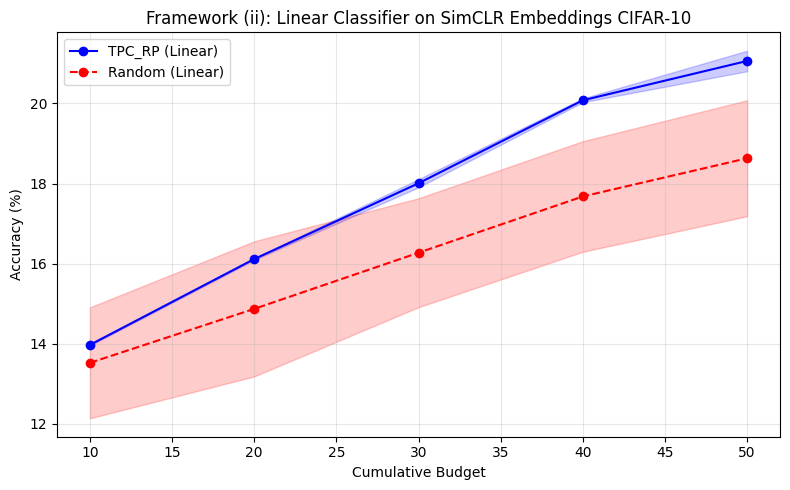

In [ ]:
# Framework (ii) — Plot and Summary Table

budgets = [BUDGET_PER_ROUND * (i+1) for i in range(NUM_ROUNDS)]

plt.figure(figsize=(8, 5))
plt.plot(budgets, linear_mean, 'b-o', label='TPC_RP (Linear)')
plt.fill_between(budgets,
                 linear_mean - linear_std,
                 linear_mean + linear_std,
                 alpha=0.2, color='blue')
plt.plot(budgets, linear_random_mean, 'r--o', label='Random (Linear)')
plt.fill_between(budgets,
                 linear_random_mean - linear_random_std,
                 linear_random_mean + linear_random_std,
                 alpha=0.2, color='red')

plt.xlabel('Cumulative Budget')
plt.ylabel('Accuracy (%)')
plt.title('Framework (ii): Linear Classifier on SimCLR Embeddings CIFAR-10')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('framework_ii_linear_results.png', dpi=150)
plt.show()

---
## 12. Framework (iii) — Semi-Supervised (FlexMatch)
### 12.1 Setup Augmentations + Load Data

In [ ]:
import torch
import numpy as np
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.transforms import RandAugment

weak_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

sstrong_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    RandAugment(num_ops=2, magnitude=10),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset_flex = datasets.CIFAR10(root='./data', train=True, download=True, transform=weak_transform)
test_dataset_flex = datasets.CIFAR10(root='./data', train=False, download=True, transform=weak_transform)
print("Datasets loaded!")

/home/sdm/.pyenv/versions/3.13.0/envs/fundus_lesion_seg/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Datasets loaded!





### 12.2 WideResNet-28 Model


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class WideResNetBlock(nn.Module):
    def __init__(self, in_planes, out_planes, stride, leaky_slope=0.1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.relu1 = nn.LeakyReLU(leaky_slope, inplace=True)
        self.conv1 = nn.Conv2d(in_planes, out_planes, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.relu2 = nn.LeakyReLU(leaky_slope, inplace=True)
        self.conv2 = nn.Conv2d(out_planes, out_planes, 3, padding=1, bias=False)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != out_planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out_planes, 1, stride=stride, bias=False)
            )

    def forward(self, x):
        out = self.conv1(self.relu1(self.bn1(x)))
        out = self.conv2(self.relu2(self.bn2(out)))
        return out + self.shortcut(x)

class WideResNet28(nn.Module):
    def __init__(self, num_classes=10, widen_factor=2, leaky_slope=0.1):
        super().__init__()
        nChannels = [16, 16*widen_factor, 32*widen_factor, 64*widen_factor]
        self.conv1 = nn.Conv2d(3, nChannels[0], 3, padding=1, bias=False)
        self.block1 = self._make_layer(nChannels[0], nChannels[1], 4, 1, leaky_slope)
        self.block2 = self._make_layer(nChannels[1], nChannels[2], 4, 2, leaky_slope)
        self.block3 = self._make_layer(nChannels[2], nChannels[3], 4, 2, leaky_slope)
        self.bn = nn.BatchNorm2d(nChannels[3])
        self.relu = nn.LeakyReLU(leaky_slope, inplace=True)
        self.fc = nn.Linear(nChannels[3], num_classes)

    def _make_layer(self, in_planes, out_planes, nb_layers, stride, leaky_slope):
        layers = [WideResNetBlock(in_planes, out_planes, stride, leaky_slope)]
        for _ in range(1, nb_layers):
            layers.append(WideResNetBlock(out_planes, out_planes, 1, leaky_slope))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = self.relu(self.bn(out))
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        return self.fc(out)

model_test = WideResNet28(widen_factor=2).to(device)
print(f"WideResNet-28 ready: {sum(p.numel() for p in model_test.parameters()):,} parameters")

WideResNet-28 ready: 1,467,610 parameters


### 12.3 FlexMatch Training Function

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

def train_flexmatch(labeled_indices, train_dataset, test_dataset, device,
                    num_iterations=400000, lr=0.03, batch_size=64,
                    threshold=0.95, widen_factor=2):

    all_indices = list(range(len(train_dataset)))
    unlabeled_indices = [i for i in all_indices if i not in labeled_indices]

    labeled_loader = DataLoader(
        Subset(train_dataset, labeled_indices),
        batch_size=min(batch_size, len(labeled_indices)), shuffle=True, drop_last=False
    )
    unlabeled_loader = DataLoader(
        Subset(train_dataset, unlabeled_indices),
        batch_size=batch_size*7, shuffle=True, drop_last=True
    )
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    model = WideResNet28(widen_factor=widen_factor).to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                          weight_decay=0.0005, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_iterations)

    class_thresholds = torch.ones(10).to(device) * threshold
    labeled_iter = iter(labeled_loader)
    unlabeled_iter = iter(unlabeled_loader)

    model.train()
    for iteration in range(num_iterations):
        try:
            x_l, y_l = next(labeled_iter)
        except StopIteration:
            labeled_iter = iter(labeled_loader)
            x_l, y_l = next(labeled_iter)

        try:
            x_u, _ = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader)
            x_u, _ = next(unlabeled_iter)

        x_l, y_l = x_l.to(device), y_l.to(device)
        x_u = x_u.to(device)

        logits_l = model(x_l)
        loss_sup = F.cross_entropy(logits_l, y_l)

        with torch.no_grad():
            probs_u = F.softmax(model(x_u), dim=1)
            max_probs, pseudo_labels = probs_u.max(dim=1)
            mask = max_probs >= class_thresholds[pseudo_labels]

            for c in range(10):
                class_mask = pseudo_labels == c
                if class_mask.sum() > 0:
                    class_thresholds[c] = 0.9 * class_thresholds[c] + \
                                          0.1 * max_probs[class_mask].mean()

        if mask.sum() > 0:
            logits_u = model(x_u)
            loss_unsup = (F.cross_entropy(logits_u, pseudo_labels, reduction='none') * mask.float()).mean()
            loss = loss_sup + loss_unsup
        else:
            loss = loss_sup

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        if iteration % 10000 == 0:
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for x_t, y_t in test_loader:
                    x_t, y_t = x_t.to(device), y_t.to(device)
                    preds = model(x_t).argmax(dim=1)
                    correct += (preds == y_t).sum().item()
                    total += y_t.size(0)
            print(f"  Iteration {iteration}: Accuracy={100*correct/total:.2f}%")
            model.train()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_t, y_t in test_loader:
            x_t, y_t = x_t.to(device), y_t.to(device)
            preds = model(x_t).argmax(dim=1)
            correct += (preds == y_t).sum().item()
            total += y_t.size(0)
    return 100 * correct / total

print("FlexMatch training function ready!")

FlexMatch training function ready!


### 12.4 TPC_RP Selection + Run FlexMatch

In [ ]:
#train_features = np.load('/content/drive/MyDrive/Colab Notebooks/simclr_features_500epochs.npy')

train_features = np.load('simclr_features_500epochs.npy')
train_labels_np = np.array(train_dataset_flex.targets)

labeled_indices_flex = typicality_clustering_select(
    features=train_features,
    budget=10,
    labeled_indices=[],
    max_clusters=500,
    k_neighbors=20
)

print(f"Selected {len(labeled_indices_flex)} examples with TPC_RP")
print(f"Classes represented: {np.unique(train_labels_np[labeled_indices_flex])}")

print("\nStarting FlexMatch training with TPC_RP labels (50k iterations)...")
flex_tpcrp_accuracy = train_flexmatch(
    labeled_indices=labeled_indices_flex,
    train_dataset=train_dataset_flex,
    test_dataset=test_dataset_flex,
    device=device,
    num_iterations=50000
)
print(f"\nFinal Accuracy (TPC_RP + FlexMatch): {flex_tpcrp_accuracy:.2f}%")

random_labeled_flex = random.sample(list(range(len(train_dataset_flex))), 10)
print(f"Random baseline: {len(random_labeled_flex)} labeled examples")

print("\nStarting FlexMatch training with random labels (50k iterations)...")
flex_random_accuracy = train_flexmatch(
    labeled_indices=random_labeled_flex,
    train_dataset=train_dataset_flex,
    test_dataset=test_dataset_flex,
    device=device,
    num_iterations=50000
)
print(f"\nFinal Accuracy (Random + FlexMatch): {flex_random_accuracy:.2f}%")
print(f"Improvement of TPC_RP over Random: {flex_tpcrp_accuracy - flex_random_accuracy:.2f}%")

  Running K-Means with 10 clusters...
Selected 10 examples with TPC_RP
Classes represented: [0 1 2 3 5 7 8]

Starting FlexMatch training with TPC_RP labels (50k iterations)...
  Iteration 0: Accuracy=11.88%
  Iteration 10000: Accuracy=12.27%
  Iteration 20000: Accuracy=11.70%
  Iteration 30000: Accuracy=13.52%
  Iteration 40000: Accuracy=12.52%

Final Accuracy (TPC_RP + FlexMatch): 14.13%
Random baseline: 10 labeled examples

Starting FlexMatch training with random labels (50k iterations)...
  Iteration 0: Accuracy=12.40%
  Iteration 10000: Accuracy=15.76%
  Iteration 20000: Accuracy=16.49%
  Iteration 30000: Accuracy=15.78%
  Iteration 40000: Accuracy=16.74%

Final Accuracy (Random + FlexMatch): 15.85%
Improvement of TPC_RP over Random: -1.72%


In [ ]:
# FlexMatch — Reps 2 and 3 (for both TPC_RP and Random)

#train_features = np.load('/content/drive/MyDrive/Colab Notebooks/simclr_features_500epochs.npy')
train_features = np.load('simclr_features_500epochs.npy')
flex_tpcrp_accuracy = 14.13
flex_random_accuracy = 15.85


flex_tpcrp_more = []
flex_random_more = []

for rep in range(1, 3):
    set_seed(rep)
    print(f"Rep {rep+1}/3")

    # TPC_RP selection
    labeled_indices_flex = typicality_clustering_select(
        features=train_features, budget=10,
        labeled_indices=[], max_clusters=500, k_neighbors=20
    )

    acc_tpcrp = train_flexmatch(
        labeled_indices=labeled_indices_flex,
        train_dataset=train_dataset_flex,
        test_dataset=test_dataset_flex,
        device=device, num_iterations=50000
    )
    flex_tpcrp_more.append(acc_tpcrp)
    print(f"TPC_RP: {acc_tpcrp:.2f}%")

    # Random selection
    random_labeled = random.sample(list(range(len(train_dataset_flex))), 10)

    acc_rand = train_flexmatch(
        labeled_indices=random_labeled,
        train_dataset=train_dataset_flex,
        test_dataset=test_dataset_flex,
        device=device, num_iterations=50000
    )
    flex_random_more.append(acc_rand)
    print(f"Random: {acc_rand:.2f}%")

# Combine all 3 reps
all_tpcrp = [flex_tpcrp_accuracy] + flex_tpcrp_more
all_random = [flex_random_accuracy] + flex_random_more

flex_tpcrp_mean = np.mean(all_tpcrp)
flex_tpcrp_std = np.std(all_tpcrp)
flex_random_mean = np.mean(all_random)
flex_random_std = np.std(all_random)

print(f"\nTPC_RP (3 reps): {all_tpcrp} → {flex_tpcrp_mean:.2f}% ± {flex_tpcrp_std:.2f}%")
print(f"Random (3 reps): {all_random} → {flex_random_mean:.2f}% ± {flex_random_std:.2f}%")

Rep 2/3
  Running K-Means with 10 clusters...
  Iteration 0: Accuracy=10.98%
  Iteration 10000: Accuracy=11.16%
  Iteration 20000: Accuracy=12.80%
  Iteration 30000: Accuracy=15.63%
  Iteration 40000: Accuracy=15.09%
TPC_RP: 12.31%
  Iteration 0: Accuracy=10.32%
  Iteration 10000: Accuracy=17.54%
  Iteration 20000: Accuracy=18.15%
  Iteration 30000: Accuracy=16.78%
  Iteration 40000: Accuracy=16.87%
Random: 16.41%
Rep 3/3
  Running K-Means with 10 clusters...
  Iteration 0: Accuracy=10.29%
  Iteration 10000: Accuracy=12.89%
  Iteration 20000: Accuracy=12.62%
  Iteration 30000: Accuracy=14.05%
  Iteration 40000: Accuracy=12.22%
TPC_RP: 13.44%
  Iteration 0: Accuracy=10.39%
  Iteration 10000: Accuracy=12.66%
  Iteration 20000: Accuracy=14.84%
  Iteration 30000: Accuracy=11.23%
  Iteration 40000: Accuracy=10.00%
Random: 9.13%

TPC_RP (3 reps): [14.13, 12.31, 13.44] → 13.29% ± 0.75%
Random (3 reps): [15.85, 16.41, 9.13] → 13.80% ± 3.31%


### Framework (iii) Results Summary

In [ ]:
print("=" * 55)
print(f"{'Method':<30} {'Accuracy':<20}")
print("=" * 55)
print(f"{'TPC_RP + FlexMatch':<30} {flex_tpcrp_mean:.2f}% ± {flex_tpcrp_std:.2f}%")
print(f"{'Random + FlexMatch':<30} {flex_random_mean:.2f}% ± {flex_random_std:.2f}%")
print(f"{'Improvement':<30} {flex_tpcrp_mean - flex_random_mean:.2f}%")
print("=" * 55)

Method                         Accuracy            
TPC_RP + FlexMatch             13.29% ± 0.75%
Random + FlexMatch             13.80% ± 3.31%
Improvement                    -0.50%


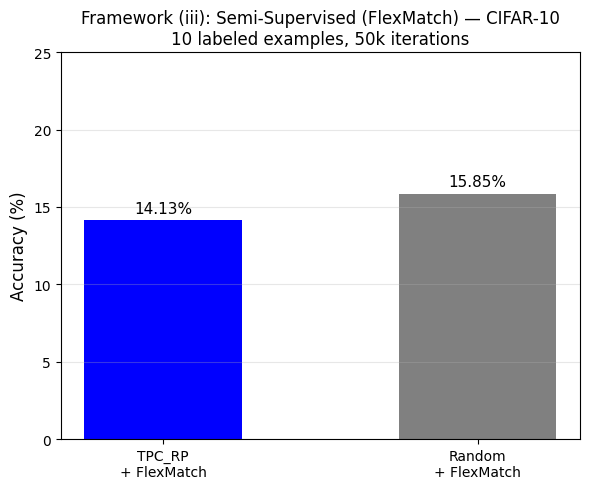

In [ ]:
# Framework (iii) bar chart — like Figure 6 in the paper
import matplotlib.pyplot as plt
import numpy as np

methods = ['TPC_RP\n+ FlexMatch', 'Random\n+ FlexMatch']
accuracies = [14.13, 15.85]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(methods, accuracies, color=['blue', 'gray'], width=0.5)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Framework (iii): Semi-Supervised (FlexMatch) — CIFAR-10\n10 labeled examples, 50k iterations', fontsize=12)
ax.set_ylim(0, 25)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('framework_iii_flexmatch.png', dpi=150)
plt.show()

---
## GitHub Repository

**TODO:** Add your GitHub repository link here:

🔗 `https://github.com/YOUR_USERNAME/YOUR_REPO_NAME`

Remember to push this notebook to your GitHub repo before submission!
